In [110]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [112]:
file_paths = [
    '/Users/aysenazsudetekel/Desktop/hangikredi/bank.csv',
    '/Users/aysenazsudetekel/Desktop/hangikredi/bank-full.csv',
    '/Users/aysenazsudetekel/Desktop/hangikredi/bank-additional.csv',
    '/Users/aysenazsudetekel/Desktop/hangikredi/bank-additional-full.csv'
]

dfs = [pd.read_csv(path , sep=';', encoding='utf-8') for path in file_paths]
df = pd.concat(dfs, ignore_index=True)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,pdays,previous,poutcome,y,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,...,339,4,failure,no,NaN,NaN,NaN,NaN,NaN,NaN
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,...,330,1,failure,no,NaN,NaN,NaN,NaN,NaN,NaN
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95039 entries, 0 to 95038
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             95039 non-null  int64  
 1   job             95039 non-null  object 
 2   marital         95039 non-null  object 
 3   education       95039 non-null  object 
 4   default         95039 non-null  object 
 5   balance         49732 non-null  float64
 6   housing         95039 non-null  object 
 7   loan            95039 non-null  object 
 8   contact         95039 non-null  object 
 9   day             49732 non-null  float64
 10  month           95039 non-null  object 
 11  duration        95039 non-null  int64  
 12  campaign        95039 non-null  int64  
 13  pdays           95039 non-null  int64  
 14  previous        95039 non-null  int64  
 15  poutcome        95039 non-null  object 
 16  y               95039 non-null  object 
 17  day_of_week     45307 non-null 

In [114]:
df = df.drop(columns=["day_of_week", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"])

In [115]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,may,226,1,-1,0,unknown,no


default 	has credit in default?		
balance		average yearly balance	
housing		has housing loan?	
loan		has personal loan?
campaign 	number of contacts performed during this campaign and for this client (numeric, includes last contact)	
pdays		number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)		yes
poutcome	Feature	Categorical		outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')	
previous	number of contacts performed before this campaign and for this client
y			has the client subscribed a term deposit?

In [116]:
missing_values = df.isna().sum()
print(missing_values)

age              0
job              0
marital          0
education        0
default          0
balance      45307
housing          0
loan             0
contact          0
day          45307
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome         0
y                0
dtype: int64


In [117]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df[['balance', 'day']] = imputer.fit_transform(df[['balance', 'day']])

In [118]:
print(df.isna().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Analyzing factors affecting customer response rates:

/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/2231197391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='poutcome', y='age', palette='colorblind')


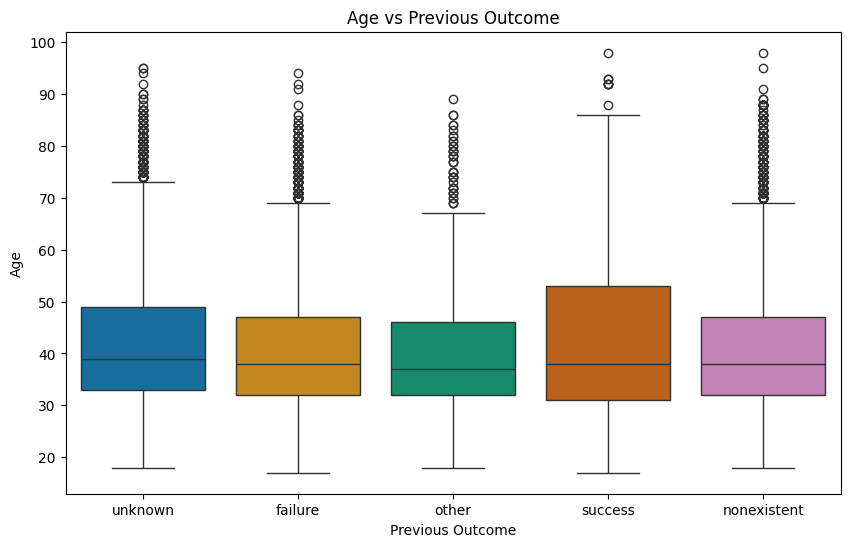

In [119]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='poutcome', y='age', palette='colorblind')
plt.title('Age vs Previous Outcome')
plt.xlabel('Previous Outcome')
plt.ylabel('Age')
plt.show()


The age group for success spans a broader range compared to failure. We can observe that the failure category is more concentrated approximately within the 30-45 age range. This could be due to factors such as differing financial needs, risk tolerance, or personal circumstances that make the campaign less appealing to those in the 30-45 age range.

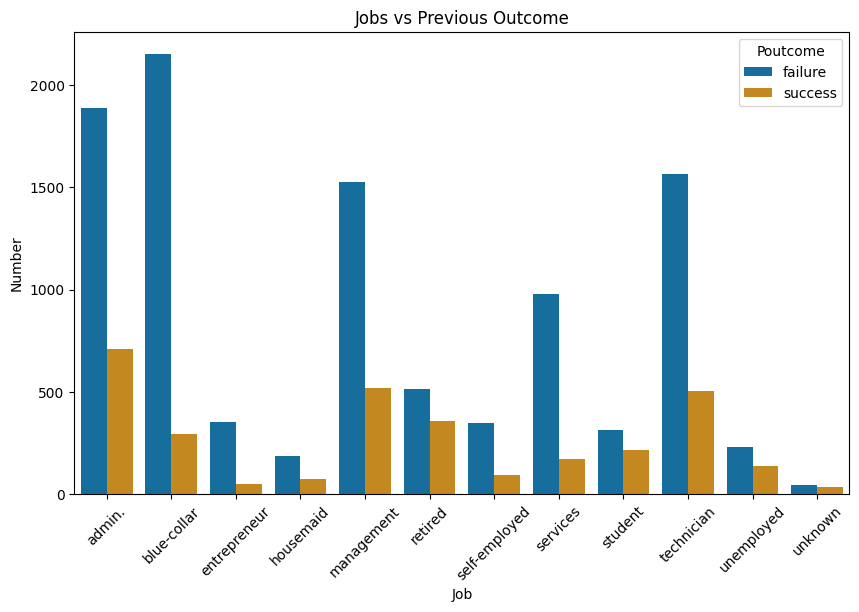

In [120]:
df_filtered = df[df['poutcome'].isin(['success', 'failure'])]
df_grouped = df_filtered.groupby(['job', 'poutcome']).size().unstack(fill_value=0)
df_grouped = df_filtered.groupby(['job', 'poutcome']).size().unstack(fill_value=0).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='job', var_name='poutcome', value_name='count'), x='job', y='count', hue='poutcome', palette='colorblind')
plt.title('Jobs vs Previous Outcome')
plt.xlabel('Job')
plt.ylabel('Number')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()

The highest success percentage is among students, retired individuals, and the unemployed. The highest success count is in the admin category, while the highest failure count is in the blue-collar category. Students, retired individuals, and the unemployed might find the bank campaign more appealing due to their immediate financial needs, greater flexibility, targeted offers, and potential benefits tailored to their financial situations. Conversely, blue-collar workers may face more financial constraints or different priorities, leading to a higher failure count.

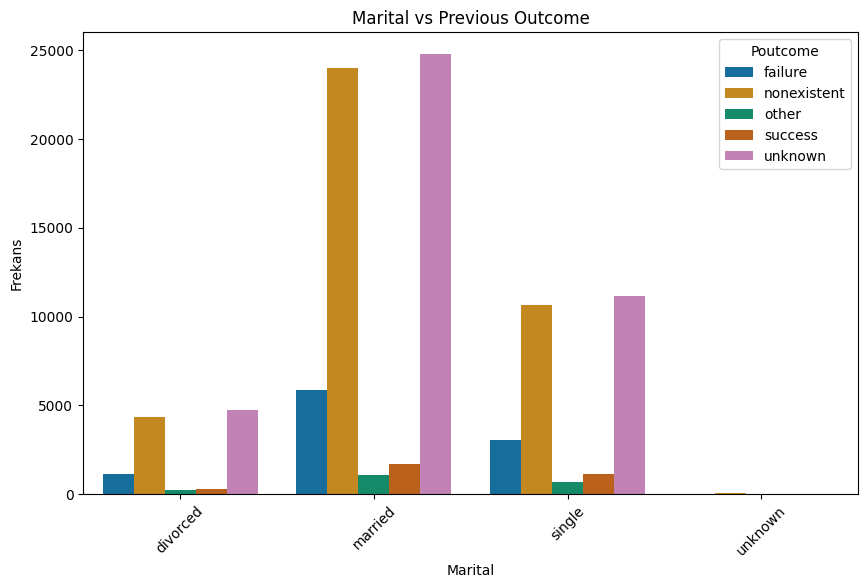

In [121]:
df_grouped=df.groupby(['marital', 'poutcome']).size().unstack(fill_value=0).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='marital', var_name='poutcome', value_name='count'), x='marital', y='count', hue='poutcome', palette='colorblind')
plt.title('Marital vs Previous Outcome')
plt.xlabel('Marital')
plt.ylabel('Frekans')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()

The higher failure rate among the married group compared to the single group suggests that married individuals may face greater financial constraints or have more complex financial commitments, making them less likely to accept the campaign. Conversely, the highest success rate in the divorced group indicates that individuals in this category might be more open to new financial opportunities or have financial situations that are more compatible with the campaign's offerings.

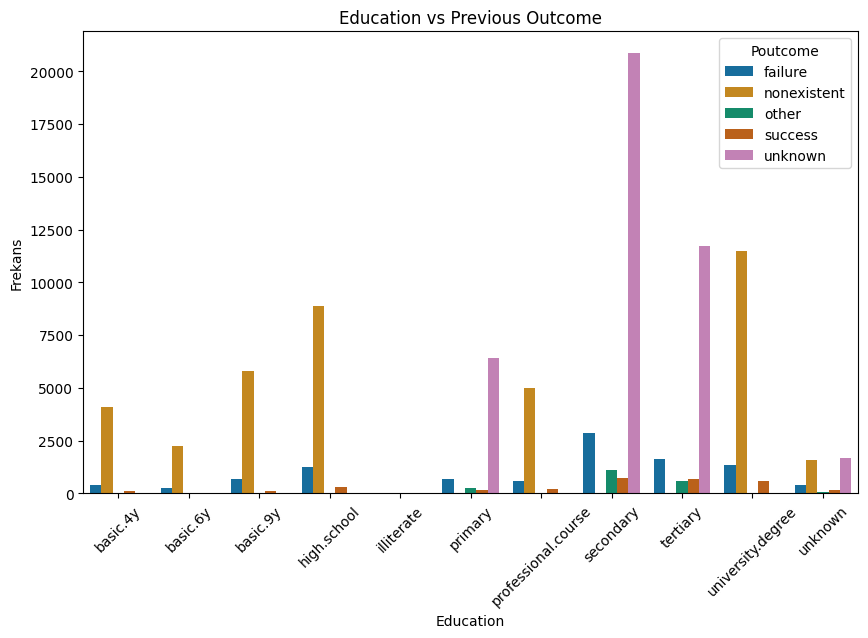

In [122]:
df_grouped=df.groupby(['education', 'poutcome']).size().unstack(fill_value=0).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='education', var_name='poutcome', value_name='count'), x='education', y='count', hue='poutcome', palette='colorblind')
plt.title('Education vs Previous Outcome')
plt.xlabel('Education')
plt.ylabel('Frekans')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()

The highest number of failures is observed in the professional course education level, while the maximum success is seen in the secondary education level.

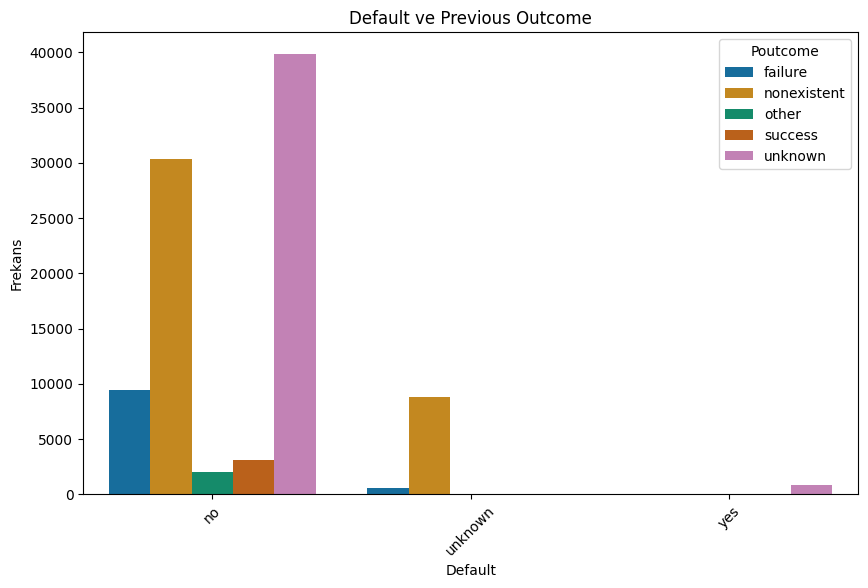

In [123]:
df_grouped = df.groupby(['default', 'poutcome']).size().unstack(fill_value=0).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='default', var_name='poutcome', value_name='count'),
            x='default', y='count', hue='poutcome', palette='colorblind')
plt.title('Default ve Previous Outcome')
plt.xlabel('Default')
plt.ylabel('Frekans')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()


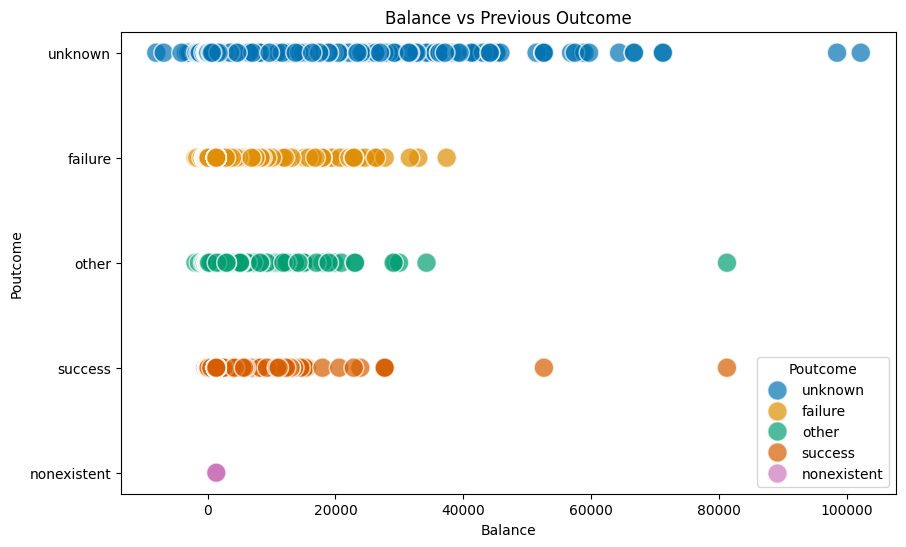

In [124]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='balance', y='poutcome', hue='poutcome', palette='colorblind', s=200, alpha=0.7)
plt.title('Balance vs Previous Outcome')
plt.xlabel('Balance')
plt.ylabel('Poutcome')
plt.legend(title='Poutcome')
plt.show()



Success shows a more concentrated distribution, whereas failure is more diverse. This suggests that individuals who accept the bank's campaign tend to have balances within a specific range, indicating that the campaign is particularly appealing to those with certain financial profiles. In contrast, the diverse range of balances among those who do not accept the campaign could imply that the campaign does not meet the needs or expectations of people with varying financial situations. Therefore, tailoring the campaign to address the financial needs of different balance groups might improve its effectiveness and acceptance rate.

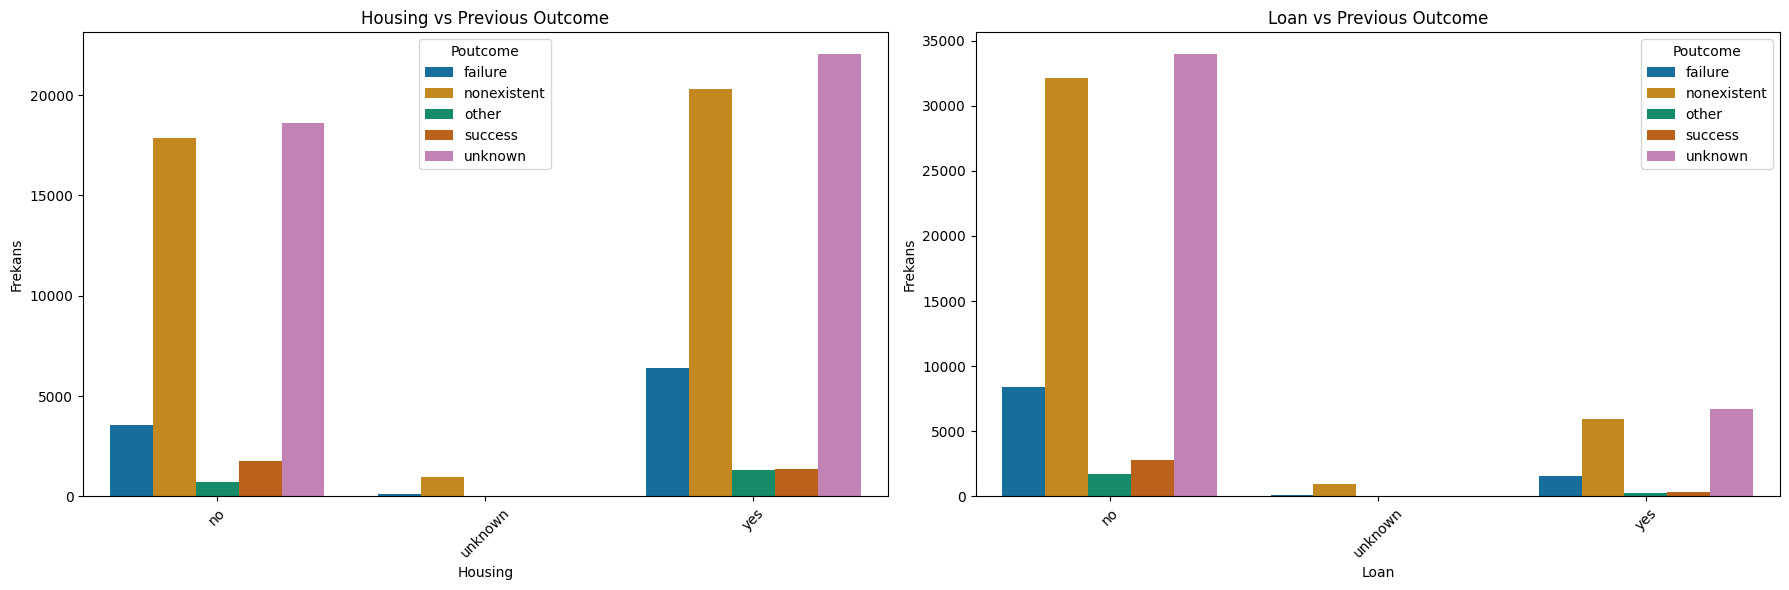

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_grouped = df.groupby(['housing', 'poutcome']).size().unstack(fill_value=0).reset_index()
sns.barplot(data=df_grouped.melt(id_vars='housing', var_name='poutcome', value_name='count'),
            x='housing', y='count', hue='poutcome', palette='colorblind', ax=axes[0])
axes[0].set_title('Housing vs Previous Outcome')
axes[0].set_xlabel('Housing')
axes[0].set_ylabel('Frekans')
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].legend(title='Poutcome')

df_grouped = df.groupby(['loan', 'poutcome']).size().unstack(fill_value=0).reset_index()
sns.barplot(data=df_grouped.melt(id_vars='loan', var_name='poutcome', value_name='count'),
            x='loan', y='count', hue='poutcome', palette='colorblind', ax=axes[1])
axes[1].set_title('Loan vs Previous Outcome')
axes[1].set_xlabel('Loan')
axes[1].set_ylabel('Frekans')
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(title='Poutcome')

plt.tight_layout()
plt.show()


People without housing loans or personal loans tend to have a higher success rate in bank campaigns. This suggests that they might be more inclined to accept offers, potentially because they don't have significant financial commitments that could make them more cautious or conservative in their decision-making. The absence of these loans could indicate greater financial flexibility, making them more open to engaging with new opportunities.

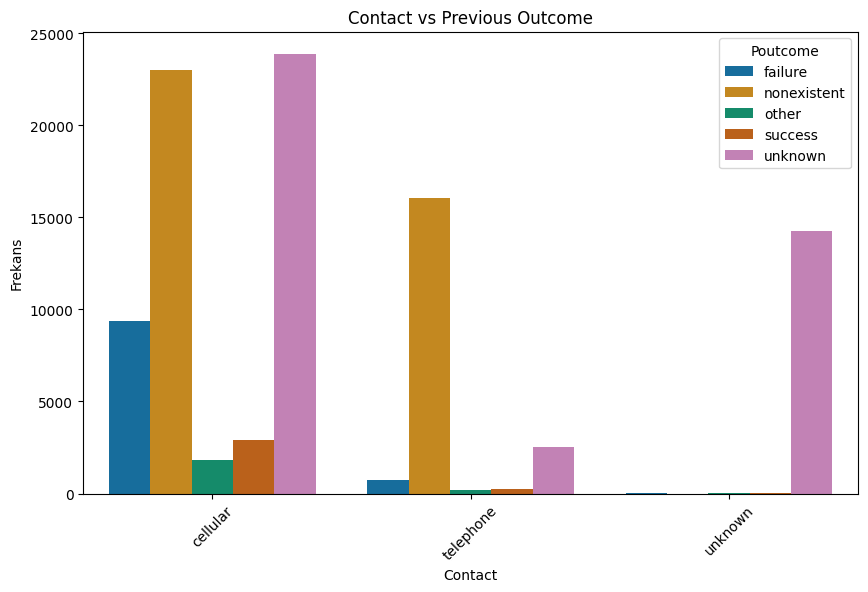

In [126]:
df_grouped = df.groupby(['contact', 'poutcome']).size().unstack(fill_value=0).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='contact', var_name='poutcome', value_name='count'),
            x='contact', y='count', hue='poutcome', palette='colorblind')
plt.title('Contact vs Previous Outcome')
plt.xlabel('Contact')
plt.ylabel('Frekans')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()


Contacting clients via cellular phones has a higher success rate in bank campaigns compared to landline telephone contact. This could be because people are generally more accessible on their mobile phones, which allows for more timely and direct communication. Additionally, mobile phones are often more personal, which might lead to a better rapport between the bank representative and the client, increasing the likelihood of a positive response.

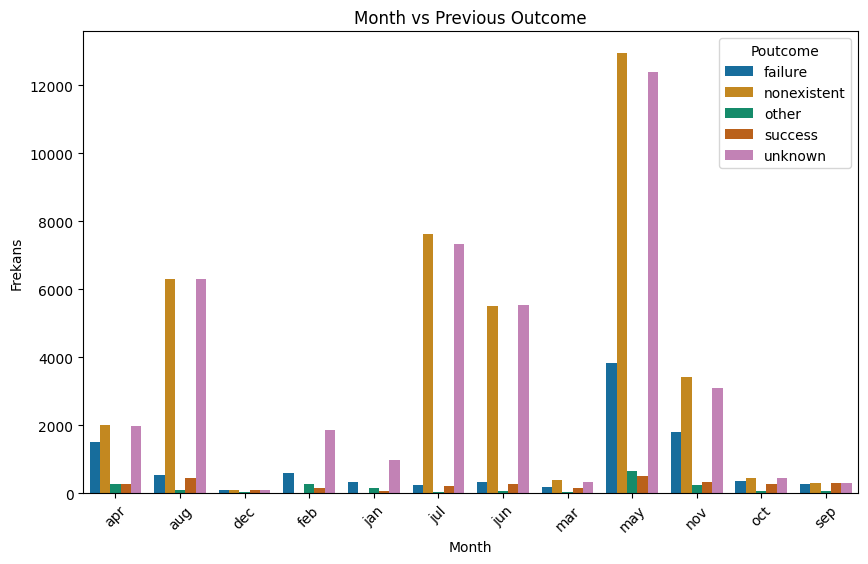

In [127]:
df_grouped = df.groupby(['month', 'poutcome']).size().unstack(fill_value=0).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='month', var_name='poutcome', value_name='count'),
            x='month', y='count', hue='poutcome', palette='colorblind')
plt.title('Month vs Previous Outcome')
plt.xlabel('Month')
plt.ylabel('Frekans')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()

/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/3212183441.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='duration', y='poutcome', alpha=0.5, palette='colorblind')


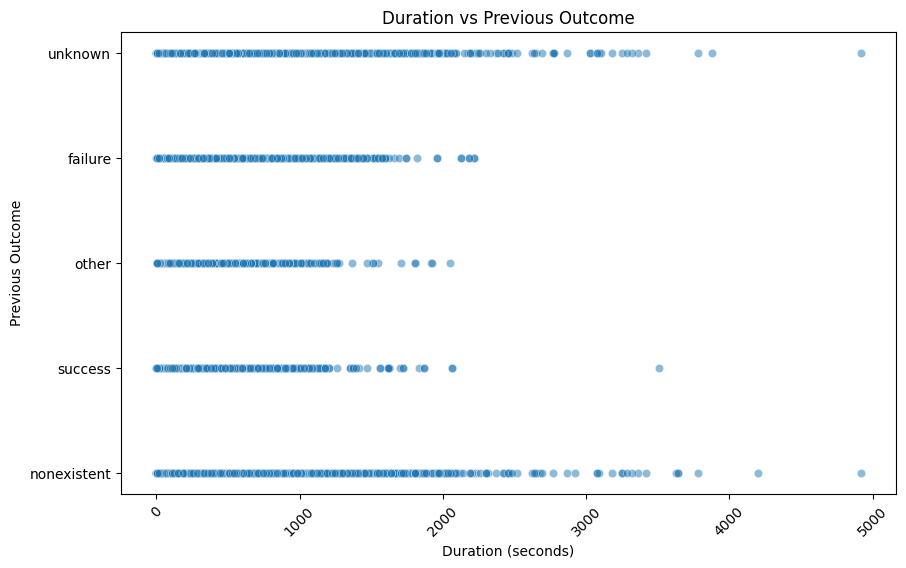

In [128]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='duration', y='poutcome', alpha=0.5, palette='colorblind')

plt.title('Duration vs Previous Outcome')
plt.xlabel('Duration (seconds)')
plt.ylabel('Previous Outcome')
plt.xticks(rotation=45)
plt.show()

Shorter conversations often lead to higher success rates because they enable direct, clear communication, keep customer attention focused, and facilitate quicker decision-making.

/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/203309750.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='campaign', y='poutcome', alpha=0.5, palette='colorblind', ax=axes[0])
/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/203309750.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='previous', y='poutcome', alpha=0.5, palette='colorblind', ax=axes[1])


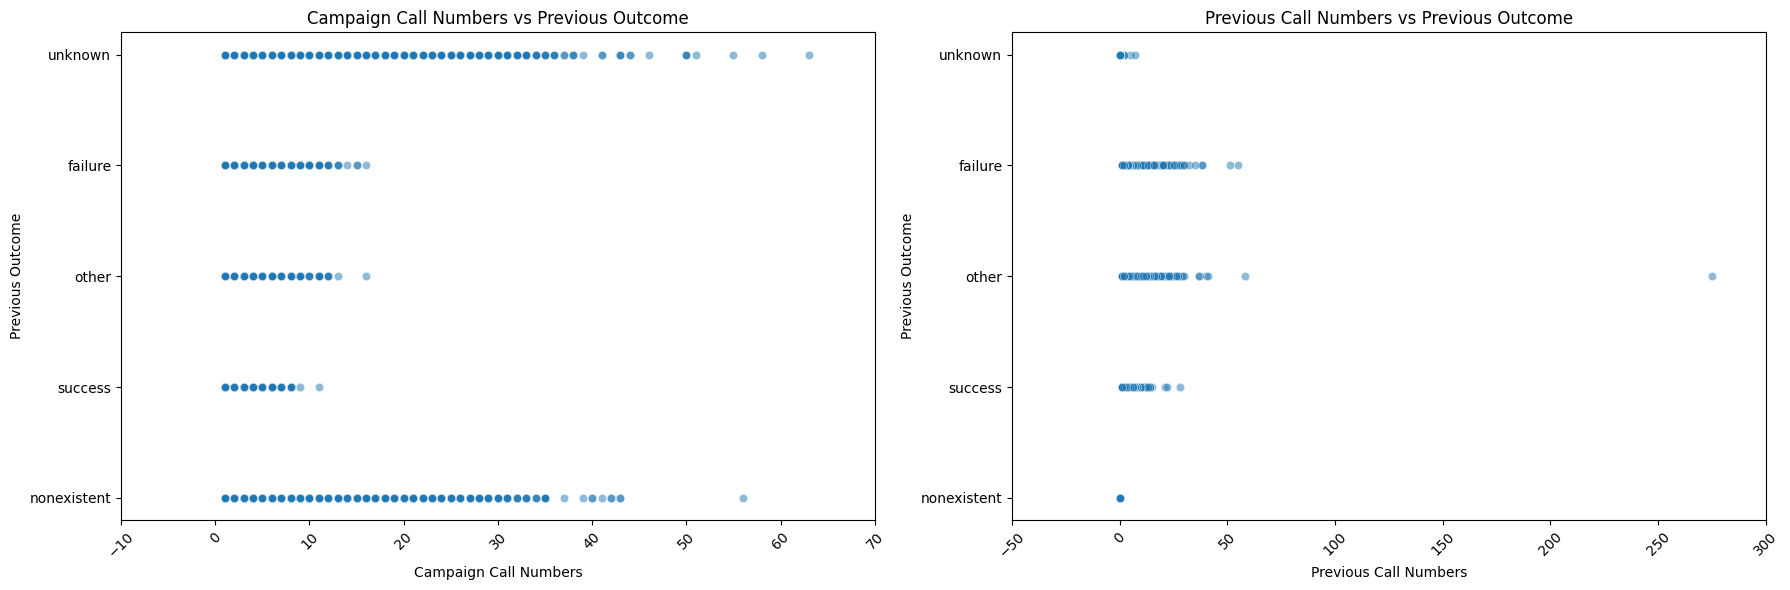

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=df, x='campaign', y='poutcome', alpha=0.5, palette='colorblind', ax=axes[0])
axes[0].set_title('Campaign Call Numbers vs Previous Outcome')
axes[0].set_xlabel('Campaign Call Numbers')
axes[0].set_ylabel('Previous Outcome')
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)


sns.scatterplot(data=df, x='previous', y='poutcome', alpha=0.5, palette='colorblind', ax=axes[1])
axes[1].set_title('Previous Call Numbers vs Previous Outcome')
axes[1].set_xlabel('Previous Call Numbers')
axes[1].set_ylabel('Previous Outcome')
axes[1].set_xticks(axes[1].get_xticks())
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()


For this campaign, customers with fewer interactions are more likely to respond positively. Customers who are contacted frequently tend to be more negative or less responsive. Additionally, the second graph shows that those who were contacted less before this campaign also tend to have a more positive response in the current campaign.

/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/2188977251.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='pdays', y='poutcome', alpha=0.5, palette='colorblind')


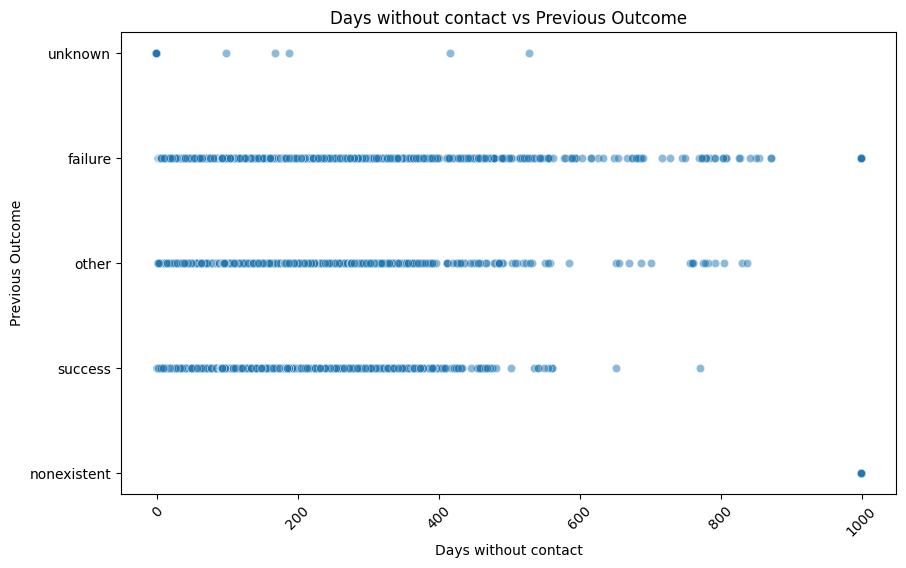

In [130]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='pdays', y='poutcome', alpha=0.5, palette='colorblind')

plt.title('Days without contact vs Previous Outcome')
plt.xlabel('Days without contact')
plt.ylabel('Previous Outcome')
plt.xticks(rotation=45)
plt.show()

As the number of days since the last contact increases, the likelihood of accepting the campaign decreases. This suggests that a longer gap between interactions may lead to decreased engagement or interest from the customer. Over time, the impact of the campaign may diminish, making customers less responsive to follow-up offers.

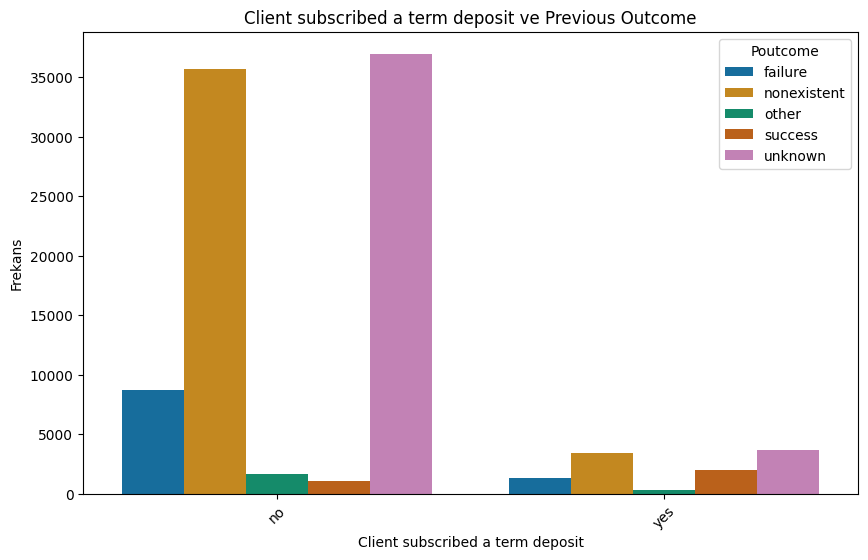

In [131]:
df_grouped = df.groupby(['y', 'poutcome']).size().unstack(fill_value=0).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=df_grouped.melt(id_vars='y', var_name='poutcome', value_name='count'),
            x='y', y='count', hue='poutcome', palette='colorblind')
plt.title('Client subscribed a term deposit ve Previous Outcome')
plt.xlabel('Client subscribed a term deposit')
plt.ylabel('Frekans')
plt.xticks(rotation=45)
plt.legend(title='Poutcome')
plt.show()

Customers who have a term deposit tend to show higher success rates in campaigns. This could be because term deposit holders are generally more financially stable and potentially more receptive to additional financial offers or benefits. Their existing relationship with the bank might also indicate a higher level of trust and engagement, making them more likely to respond positively to new campaign offers.

In [132]:
from scipy.stats import chi2_contingency
categorical_columns = ["job","marital","housing", "loan", "contact","y"]
for column in categorical_columns:
    if column != 'poutcome':
        contingency_table = pd.crosstab(df[column], df['poutcome'])
        chi2, p, _, _ = chi2_contingency(contingency_table)
        print(f"p-value between {column} and previous outcome : {p}")

p-value between job and previous outcome : 0.0
p-value between marital and previous outcome : 2.2045031191045254e-49
p-value between housing and previous outcome : 0.0
p-value between loan and previous outcome : 4.665189912119057e-238
p-value between contact and previous outcome : 0.0
p-value between y and previous outcome : 0.0


In [133]:
pd.crosstab(df["job"], df['poutcome'])

poutcome,failure,nonexistent,other,success,unknown
job,,,,,
admin.,1888,9768,267,707,4453
blue-collar,2153,9021,438,295,8909
entrepreneur,351,1406,46,49,1407
housemaid,185,1052,30,73,1182
management,1527,2772,442,517,8417
retired,514,1461,88,359,1958
self-employed,348,1378,70,93,1453
services,977,3788,193,172,3803
student,315,647,89,213,715


Değerleri kontrol ettik crosstabde 0 değerimiz yok. O zaman p-value çok küçük olduğu için 0 veriyor diyebiliriz. Yani üstteki değerlerin hepsi arada significant bir ilişki olduğunu gösteriyor.

In [134]:
from scipy.stats import ttest_ind

binary_categorical_columns = ["poutcome"]  
continuous_variables = ["balance", "duration", "campaign", "pdays"]  

for cat_column in binary_categorical_columns:
    for cont_column in continuous_variables:
        categories = df[cat_column].unique()
        group1 = df[df[cat_column] == categories[0]][cont_column]
        group2 = df[df[cat_column] == categories[1]][cont_column]
        
        t_stat, p_value = ttest_ind(group1, group2, equal_var=False)  # Welch's t-test için equal_var=False
        
        print(f"T-test between {cat_column} and {cont_column}:")
        print(f"T-statistic: {t_stat}, p-value: {p_value}\n")



T-test between poutcome and balance:
T-statistic: -4.196436622260712, p-value: 2.7216455923816924e-05

T-test between poutcome and duration:
T-statistic: 4.314235147993366, p-value: 1.610460780329809e-05

T-test between poutcome and campaign:
T-statistic: 42.22172038769413, p-value: 0.0

T-test between poutcome and pdays:
T-statistic: -149.4502774655648, p-value: 0.0



Evet significant bir ilişki var.

p-value is less than 0.05 between education-y, default-y, housing-y, loan-y so there are relationships between these.

CUSTOMER SEGMENTATION

In [135]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [136]:
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
numerical_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [137]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

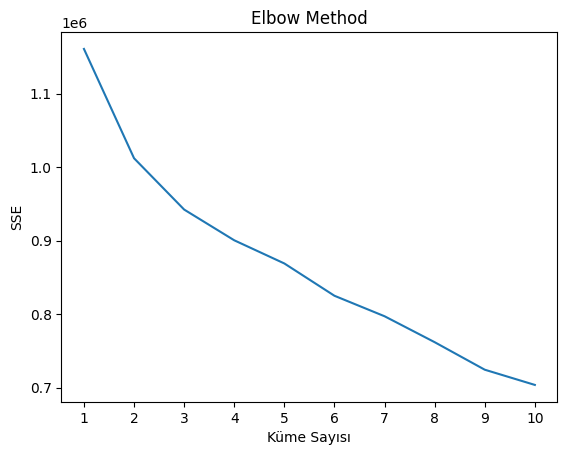

In [138]:
kmeans_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('kmeans', KMeans(n_clusters=4, random_state=42))])

# Modeli fit etme
kmeans_pipeline.fit(df)

# Küme etiketlerini alma
clusters = kmeans_pipeline.named_steps['kmeans'].labels_

# Kümeleri veriye ekleme
df['cluster'] = clusters

# Kümelerin sayısını belirlemek için elbow methodu
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(preprocessor.fit_transform(df))
    sse.append(kmeans.inertia_)

# SSE'yi görselleştirme
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel('Küme Sayısı')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()


SSE, Sum of Squared Errors (Hataların Karesinin Toplamı) anlamına gelir ve kümeleme algoritmalarında (özellikle K-Means'te) kümeleme performansını değerlendirmek için kullanılan bir metriktir. Her bir kümedeki veri noktalarının küme merkezine (centroid) olan uzaklıklarının karesini alarak hesaplanır.

SSE'nin amacı nedir?
SSE, kümelerin ne kadar sıkı olduğunu gösterir. Daha düşük bir SSE, veri noktalarının küme merkezine daha yakın olduğunu ve dolayısıyla kümenin daha sıkı ve homojen olduğunu gösterir. Bu, kümeleme modelinin veriyi daha iyi temsil ettiği anlamına gelir. Küme merkezinden uzak olan veri noktaları ise kümelerin daha dağınık olduğu anlamına gelir ve SSE artar.

K-Means'te SSE Nasıl Kullanılır?
Küme sayısını seçmek için: K-Means algoritmasında ideal küme sayısını seçmek için genellikle elbow method kullanılır. Farklı küme sayılarında (k) SSE hesaplanır ve grafiğe dökülür.
Grafikte, SSE genellikle küme sayısı arttıkça azalır, çünkü her yeni küme veriyi daha iyi temsil eder.
Ancak belirli bir noktadan sonra (elbow noktası), SSE'deki azalma hızı yavaşlar. Bu nokta, ideal küme sayısını belirlemeye yardımcı olur.

n: Kümedeki veri noktalarının sayısı
Bu formül, her bir veri noktasının küme merkezine olan uzaklığının karesini alıp, bu kareleri toplar.

Özet
SSE, bir kümeleme modelinin başarısını ölçen bir metriktir. Daha düşük SSE, kümelerin veriyi daha iyi temsil ettiğini gösterir. Elbow method ile grafikte keskin bir dirsek (elbow) gördüğünüz nokta, en uygun küme sayısının işareti olabilir


Bu kodun amacı, müşteri segmentasyonu yaparak verideki müşterileri belirli özelliklerine göre gruplara ayırmaktır. Müşteri segmentasyonu, benzer özelliklere sahip müşterilerin bir araya getirilerek farklı gruplara ayrılmasını sağlar. Bu sayede pazarlama stratejileri her bir müşteri segmentine göre uyarlanabilir ve daha verimli kampanyalar yapılabilir.

Ne Yapıyoruz?
Veriyi Hazırlama: İlk olarak verinizde kategorik ve sayısal özellikleri belirliyoruz. Kategorik veriler metin olduğu için makine öğrenmesi algoritmalarıyla çalışabilmesi adına sayısal verilere dönüştürülüyor (OneHotEncoder ile). Sayısal veriler ise bir ölçekte olmadığı için (örneğin, 'age' ile 'balance' farklı ölçeklerde olabilir) standardize ediliyor (StandardScaler ile).

Segmentasyon: Veriyi hazırladıktan sonra, K-Means algoritmasını kullanarak veriyi farklı gruplara ayırıyoruz. K-Means algoritması, müşterileri benzer özelliklere göre kümeleyerek onları gruplara ayırıyor. Örneğin, yüksek gelirli ve genç müşteriler bir kümeye, düşük gelirli ve yaşlı müşteriler başka bir kümeye atanabilir.

Küme Sayısını Belirleme (Elbow Method): Küme sayısını doğru seçmek önemlidir. Bu yüzden, 'elbow method' denilen bir teknikle, farklı küme sayılarında algoritmanın ne kadar iyi performans gösterdiğini inceleyip en uygun küme sayısını belirliyoruz.

Sonuç Nedir?
Müşteri segmentasyonuyla, müşterilerinizi örneğin 4 farklı kümeye ayırmış oluyorsunuz. Her küme benzer özelliklere sahip müşterileri temsil eder ve bu sayede:

Her segment için daha hedefli kampanyalar yapabilirsiniz.
Hangi müşteri gruplarının hangi kampanyalara daha iyi tepki verdiğini anlayabilirsiniz.
Eğer müşteri segmentasyonuna ihtiyacınız olup olmadığını soruyorsanız: Pazarlama stratejilerini kişiselleştirmek ve her müşteri grubuna uygun teklifler sunmak için segmentasyon kullanılır.

In [139]:
# Küme numaralarını veri setine ekleme
df['cluster'] = clusters

# İlk 10 müşteri ve hangi kümeye atandıkları
print(df[['age', 'balance', 'job', 'education', 'cluster']].head(10))


   age  balance            job  education  cluster
0   30   1787.0     unemployed    primary        0
1   33   4789.0       services  secondary        2
2   35   1350.0     management   tertiary        2
3   30   1476.0     management   tertiary        2
4   59      0.0    blue-collar  secondary        2
5   35    747.0     management   tertiary        0
6   36    307.0  self-employed   tertiary        2
7   39    147.0     technician  secondary        2
8   41    221.0   entrepreneur   tertiary        2
9   43    -88.0       services    primary        2


In [140]:
# Sadece sayısal sütunları seçelim
numeric_columns = df.select_dtypes(include=['int64', 'float64'])

# Gruplandırma işlemini sadece sayısal sütunlarda yapalım
cluster_summary = df.groupby('cluster')[numeric_columns.columns].mean()

# Sonucu görelim
print(cluster_summary)



               age      balance        day     duration  campaign       pdays  \
cluster                                                                         
0        40.907551  1596.733383  23.086876   204.653129  3.339655   20.578104   
1        39.961662  1367.836632  15.817063   204.916816  2.600592  998.924229   
2        41.060211  1147.868029   9.414056   222.524531  2.230665   54.843181   
3        40.478322  1447.459170  15.737683  1019.163068  2.488327  506.770405   

         previous  
cluster            
0        0.285708  
1        0.117437  
2        0.901799  
3        0.366860  


In [141]:
# Her kümede hangi mesleklerin dağılımı olduğunu görmek için
print(df.groupby('cluster')['job'].value_counts())


cluster  job          
0        management        5190
         blue-collar       4425
         technician        4117
         admin.            2501
         services          1985
         retired           1024
         self-employed      859
         entrepreneur       809
         unemployed         635
         housemaid          634
         student            403
         unknown            144
1        admin.           10256
         blue-collar       9329
         technician        6733
         services          4008
         management        2927
         retired           1576
         entrepreneur      1468
         self-employed     1426
         housemaid         1069
         unemployed         999
         student            751
         unknown            331
2        blue-collar       5733
         management        4774
         technician        4059
         admin.            3364
         services          2402
         retired           1475
         self-emp

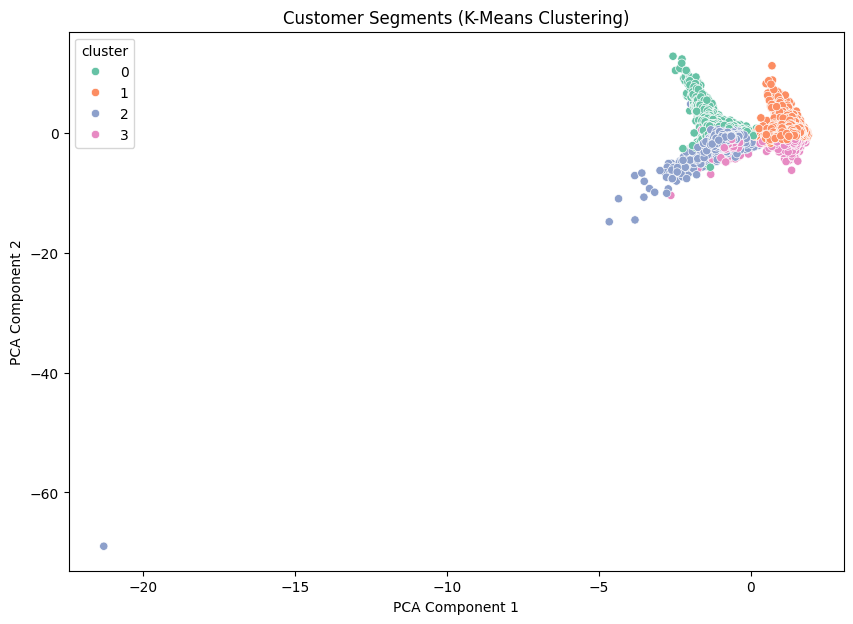

In [142]:
from sklearn.decomposition import PCA
import seaborn as sns

# PCA ile veriyi 2 boyuta indirme
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(preprocessor.fit_transform(df))

# Küme numaralarına göre scatter plot oluşturma
plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=df['cluster'], palette='Set2')
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()



Bu kod, verinizdeki özellikleri (columns) PCA (Principal Component Analysis) kullanarak 2 boyuta indirger ve her bir müşteriyi 2 boyutlu bir grafikte gösterir. Bu grafikte, her müşteri kümelere göre renklendirilmiş olarak gösterilir ve K-Means kümeleme sonuçlarını görselleştirmiş olursunuz. Şimdi adım adım açıklayalım:

PCA (Temel Bileşen Analizi): Çok boyutlu veriyi, verinin temel özelliklerini (en fazla varyansı) koruyarak daha düşük boyutlara indirger. Bu örnekte, veriyi 2 boyuta indiriyoruz (n_components=2). Bu, verinizdeki karmaşık çok boyutlu yapıyı görselleştirmeye uygun bir hale getirir.

preprocessor.fit_transform(df): Veriniz üzerinde ön işleme (örneğin, normalizasyon, standardizasyon) uygulandıktan sonra PCA işlemi yapılır. Bu, verinizdeki sayısal ve kategorik verileri doğru bir şekilde işlemek içindir.


pca.fit_transform(...): PCA, veriyi 2 bileşene indirger. Bu bileşenler, verinin en fazla varyansını (bilgiyi) temsil eder ve veriyi daha düşük bir boyuta indirir.
Sonuç olarak, her müşteri artık 2 boyutlu bir nokta (bir x ve bir y değeri) olarak temsil edilir ve bu noktalar reduced_data adlı değişkende tutulur.

Figure oluşturma: plt.figure(figsize=(10, 7)) grafiğin boyutunu ayarlar. Burada grafiğin genişliği 10, yüksekliği ise 7 birim olarak ayarlanmıştır.

Scatter plot çizimi: sns.scatterplot() fonksiyonu kullanılarak her müşteri bir nokta olarak çizilir.

x=reduced_data[:, 0]: İlk PCA bileşenini (x ekseni) kullanarak her müşteriyi grafikte yatay eksende gösterir.
y=reduced_data[:, 1]: İkinci PCA bileşenini (y ekseni) kullanarak her müşteriyi dikey eksende gösterir.


hue=df['cluster']: Kümeleri farklı renklere göre ayırır. Her küme farklı renkte gösterilir.
palette='Set2': Renklendirme için bir palet seçilir. Set2 paleti pastel renklerden oluşan bir palettir.
Başlık ve etiketler: Grafiğin başlığı ve eksen isimleri belirlenir:

plt.title('Customer Segments (K-Means Clustering)'): Grafiğin başlığı, müşteri segmentlerinin gösterildiğini belirtir.
plt.xlabel('PCA Component 1') ve plt.ylabel('PCA Component 2'): X ve Y eksenlerine "PCA Component 1" ve "PCA Component 2" isimleri verilir. Bu bileşenler, verinin boyutunu 2 bileşene indirgeyen PCA'nın bir çıktısıdır.
plt.show(): Grafiği ekrana getirir ve görselleştirme işlemini tamamlar.

Özet:
Bu kod, çok boyutlu verinizi 2 boyuta indirip, K-Means algoritmasıyla kümelenmiş müşterileri bir grafik üzerinde gösterir. Her nokta bir müşteri ve her renk bir küme (segment) olarak görselleştirilir. Bu sayede müşteri segmentasyonunu görsel olarak analiz edebilir ve kümelerin nasıl dağıldığını anlayabilirsiniz.


Müşteri segmentasyonu, müşteri kitlenizi belirli özelliklere göre gruplara ayırma işlemidir. Bu işlem, özellikle pazarlama, satış stratejileri ve müşteri ilişkileri yönetiminde oldukça faydalıdır. Aşağıda bu segmentasyonun işinize nasıl yarayabileceğini daha detaylı anlatacağım:

1. Kişiselleştirilmiş Pazarlama
Her müşteri grubunun farklı ihtiyaçları, tercihleri ve davranışları olabilir. Segmentasyon sayesinde:

Her bir küme için kişiselleştirilmiş pazarlama kampanyaları oluşturabilirsiniz.
Örneğin, genç müşterilere farklı ürünler veya promosyonlar sunarken, yaşlı müşterilere daha uygun tekliflerle yaklaşırsınız.
Müşterilere daha uygun teklifler sunarak, dönüşüm oranlarınızı artırabilirsiniz.
2. Hedefleme ve Müşteri Profilleme
Segmentasyon, her müşteri grubu için bir profil çıkartmanıza olanak tanır:

Hangi müşteri segmentlerinin daha değerli olduğunu öğrenebilirsiniz (örneğin, daha yüksek harcama yapan ya da sadık olan gruplar).
Kârınızı artıran gruplara odaklanabilir ve bu grupları elde tutmak için daha fazla kaynak ayırabilirsiniz.
Düşük değerli veya düşük ilgi gösteren segmentlere farklı stratejiler uygulayarak maliyetlerinizi optimize edebilirsiniz.
3. Yeni Ürün Geliştirme
Segmentasyon, farklı müşteri gruplarının ihtiyaçlarını anlamanıza yardımcı olur:

Her segmentin neye ihtiyaç duyduğunu anlamak, yeni ürünler geliştirirken müşteri odaklı inovasyon yapmanızı sağlar.
Örneğin, genç bir müşteri segmentinin teknolojik ürünlere ilgisi varsa, bu doğrultuda yeni ürünler geliştirebilirsiniz.
4. Müşteri Sadakati ve Kaybını Önleme
Her segmentin müşteri davranışını analiz ederek:

Müşteri kaybını azaltma stratejileri geliştirebilirsiniz.
Sadık müşteriler için sadakat programları oluşturabilir, onlara özel indirimler ve avantajlar sunabilirsiniz.
Risk altında olan müşteri gruplarını tespit edip, onları kaybetmeden önce proaktif adımlar atabilirsiniz.
5. Kaynak Yönetimi
Segmentasyon, hangi müşteri gruplarına ne kadar kaynak ayırmanız gerektiği konusunda bilgi verir:

Daha fazla yatırım yapmanız gereken müşteri segmentlerini belirleyebilirsiniz.
Kaynaklarınızı daha verimli kullanarak maliyetlerinizi düşürebilir ve kâr marjınızı artırabilirsiniz.
6. Fiyatlandırma Stratejileri
Farklı müşteri segmentlerine farklı fiyatlandırma stratejileri uygulayabilirsiniz:

Fiyat duyarlılığı yüksek olan müşterilere uygun fiyatlar sunarken, daha yüksek gelirli segmentlere premium fiyatlandırma stratejileri uygulayabilirsiniz.
7. Müşteri İlişkileri Yönetimi (CRM)
Her segmentin ihtiyaçlarına ve davranışlarına göre:

Müşterilerle daha etkin iletişim kurabilirsiniz.
CRM sisteminizi optimize ederek her bir segmentle daha doğru bir şekilde etkileşimde bulunabilirsiniz.
Örnek: Bankacılık Sektörü
Eğer bankacılık sektöründeyseniz, bu segmentasyonla şunları yapabilirsiniz:

Kredi tekliflerini, her segmentin finansal durumuna ve kredi geçmişine göre kişiselleştirebilirsiniz.
Yeni ürün (örneğin, yatırım araçları) tanıtımlarını en ilgili müşteri segmentine yaparak dönüşüm oranlarını artırabilirsiniz.
Mevcut müşterilerinizden daha fazla değer elde etmek için sadık müşterilere yönelik kampanyalar düzenleyebilirsiniz.
Sonuç
Müşteri segmentasyonu, veriye dayalı kararlar alarak işinizi daha kârlı ve etkili bir şekilde yönetmenizi sağlar. Müşterilerinizi tanımak, onlara uygun hizmet ve ürünler sunarak müşteri memnuniyetini ve sadakatini artırmanıza yardımcı olur.

/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/2881838532.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = label_encoder.fit_transform(data[col])
/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/2881838532.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = label_encoder.fit_transform(data[col])
/var/folders/cq/01_d5fpd1yx65brymy7ynbdh0000gn/T/ipykernel_1169/2881838532.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

Model Accuracy: 0.984743265993266
Confusion Matrix:
[[18312    76]
 [  214   406]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     18388
           1       0.84      0.65      0.74       620

    accuracy                           0.98     19008
   macro avg       0.92      0.83      0.86     19008
weighted avg       0.98      0.98      0.98     19008



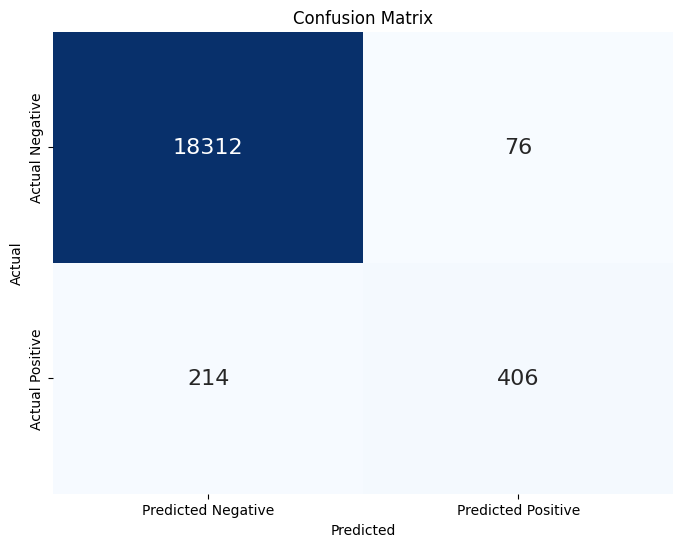

In [143]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi Hazırlama
# Önemli sütunları seçiyoruz (demografik bilgiler, segmentasyon sonucu ve önceki kampanya sonucu)
selected_columns = ['age', 'job', 'marital', 'education', 'balance', 'housing', 'loan', 
                    'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'cluster']
data = df[selected_columns]

# 2. Kategorik verileri sayısal verilere çevirme
# Label Encoding uygulayarak kategorik değişkenleri sayısallaştırıyoruz
label_encoder = LabelEncoder()
categorical_columns = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'poutcome']

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

# Hedef değişken (target): poutcome kullanıyoruz
# Eğer "success" varsa 1, diğer durumlarda 0 yapıyoruz
data['poutcome'] = data['poutcome'].apply(lambda x: 1 if x == label_encoder.transform(['success'])[0] else 0)

# 3. Veriyi Eğitim ve Test Setlerine Bölme
X = data.drop('poutcome', axis=1)  # Bağımsız değişkenler
y = data['poutcome']  # Hedef değişken

# Veriyi %80 eğitim, %20 test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Veriyi Ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Modeli Eğitme - Random Forest kullanıyoruz
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# 6. Model Performansı
y_pred = model.predict(X_test_scaled)

# Sonuçları değerlendirme
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Sonuçları yazdırma
print(f"Model Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Confusion matrix'i görselleştirme
conf_matrix_df = pd.DataFrame(conf_matrix, 
                              index=['Actual Negative', 'Actual Positive'], 
                              columns=['Predicted Negative', 'Predicted Positive'])

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False, 
            annot_kws={"size": 16})
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


Bu confusion matrix'in öğeleri şunları ifade eder:

True Negatives (TN): Modelin doğru bir şekilde "negatif" olarak sınıflandırdığı gerçek negatif örnekler. Burada 18,312.
False Positives (FP): Modelin yanlış bir şekilde "pozitif" olarak sınıflandırdığı gerçek negatif örnekler. Burada 76.
False Negatives (FN): Modelin yanlış bir şekilde "negatif" olarak sınıflandırdığı gerçek pozitif örnekler. Burada 214.
True Positives (TP): Modelin doğru bir şekilde "pozitif" olarak sınıflandırdığı gerçek pozitif örnekler. Burada 406.

Doğruluk (Accuracy):
Modelinizin doğruluk oranı yaklaşık %98.8.

Hassasiyet (Precision):
Pozitif sınıflandırılan örneklerin ne kadarının gerçekten pozitif olduğunu gösterir; burada yaklaşık %84.2.

Duyarlılık (Recall):
Gerçek pozitif örneklerin ne kadarının doğru sınıflandırıldığını gösterir; burada yaklaşık %65.5.

F1 Skoru (F1 Score):
Hassasiyet ve duyarlılığın dengeli bir ölçüsüdür; burada yaklaşık %74.3.

Yorum
Modelinizin genel doğruluğu yüksek, yani çoğu tahmin doğru. Ancak, hassasiyet ve duyarlılık arasında bir dengesizlik var. Model, pozitif örnekleri doğru tahmin etmede biraz zorluk yaşıyor (Recall düşük), ancak pozitif tahminlerin çoğu doğru (Precision yüksek).
False Negatives (FN) oranı yüksek, yani gerçek pozitif örneklerin bir kısmı negatif olarak sınıflandırılmış. Bu, modelin bazı önemli pozitif durumları kaçırdığını gösterir.
False Positives (FP) oranı düşük, yani model pozitif tahminlerde bulunurken çoğu zaman doğru tahmin yapıyor.
Bu sonuçlar, modelinizin genel olarak iyi performans gösterdiğini, ancak pozitif sınıfları daha iyi tahmin etmek için bazı iyileştirmelere ihtiyaç duyabileceğini gösterir. Modelinizin hatalarını anlamak ve iyileştirmek için bu tür analizler oldukça faydalıdır.

Model Accuracy: 0.9673821548821548
Confusion Matrix:
[[18388     0]
 [  620     0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18388
           1       0.00      0.00      0.00       620

    accuracy                           0.97     19008
   macro avg       0.48      0.50      0.49     19008
weighted avg       0.94      0.97      0.95     19008



/Users/aysenazsudetekel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aysenazsudetekel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/aysenazsudetekel/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

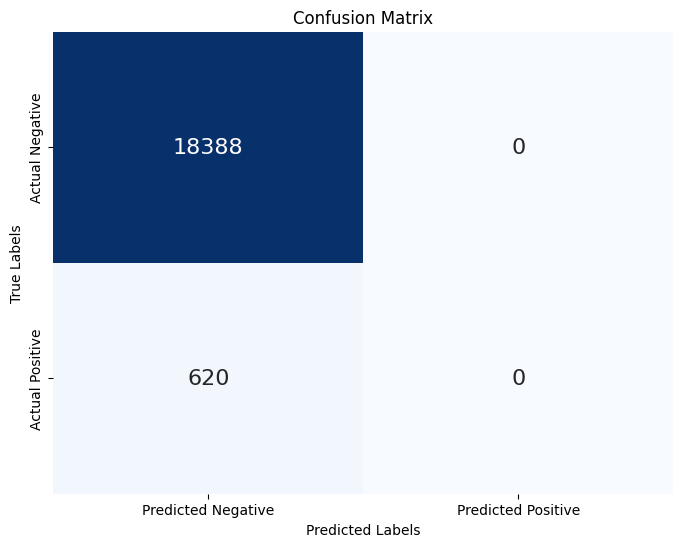

In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi Hazırlama
# Yalnızca 'cluster' ve 'poutcome' sütunlarını kullanarak veri setini oluştur
df_cluster = df[['cluster', 'poutcome']]

# Hedef değişken (target): 'poutcome' kullanılıyor
X = df_cluster[['cluster']]
y = df_cluster['poutcome']

# Eğitim ve test setlerine bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli Eğitme - Random Forest kullanıyoruz
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Model Performansı
y_pred = model.predict(X_test)

# Sonuçları değerlendirme
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Sonuçları yazdırma
print(f"Model Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix hesapla
conf_matrix = confusion_matrix(y_test, y_pred)

# Confusion matrix'i bir DataFrame'e dönüştür
conf_matrix_df = pd.DataFrame(conf_matrix, 
                              index=['Actual Negative', 'Actual Positive'], 
                              columns=['Predicted Negative', 'Predicted Positive'])

# Confusion matrix'i görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues', cbar=False, 
            annot_kws={"size": 16})
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()



Bu matrix'in öğeleri şunları ifade eder:

True Negatives (TN): Modelin doğru bir şekilde "negatif" olarak sınıflandırdığı gerçek negatif örnekler. Burada 18,388.
False Positives (FP): Modelin yanlış bir şekilde "pozitif" olarak sınıflandırdığı gerçek negatif örnekler. Burada 0.
False Negatives (FN): Modelin yanlış bir şekilde "negatif" olarak sınıflandırdığı gerçek pozitif örnekler. Burada 620.
True Positives (TP): Modelin doğru bir şekilde "pozitif" olarak sınıflandırdığı gerçek pozitif örnekler. Burada 0.


Doğruluk (Accuracy):Modelinizin doğruluk oranı yaklaşık %96.7.

Hassasiyet (Precision):Bu durumda, hassasiyet hesaplanamaz çünkü model hiçbir pozitif tahminde bulunmamış.

Duyarlılık (Recall):Modeliniz, gerçek pozitif örneklerin hiçbirini doğru tahmin edememiş, bu yüzden duyarlılık sıfır.

F1 Skoru (F1 Score):Bu durumda, F1 skoru hesaplanamaz çünkü Precision ve Recall sıfır.

Modeliniz, tüm pozitif örnekleri negatif olarak sınıflandırmış. Bu, modelin pozitif sınıfları tanımada tamamen başarısız olduğunu gösterir.
Doğruluk (Accuracy) yüksek, ancak bu yanıltıcı olabilir. Modeliniz, sadece negatif sınıfları doğru tahmin ediyor ve pozitif sınıfları tamamen kaçırıyor. Bu nedenle, yalnızca doğruluk metriği modelin başarısını doğru yansıtmaz.
Hassasiyet, duyarlılık ve F1 skoru sıfır; bu, modelin pozitif örnekleri tahmin etmede tamamen başarısız olduğunu gösterir.
Öneriler
Modelinizin veri dengesizliği (pozitif ve negatif örnekler arasındaki büyük fark) nedeniyle kötü performans gösterdiği olabilir. Verilerinizi dengelemek için örnekleme yöntemleri (SMOTE, ADASYN vb.) veya ağırlık ayarlamaları yapmayı düşünebilirsiniz.
Model hiperparametrelerini ayarlamayı veya farklı model türlerini denemeyi düşünebilirsiniz.
Veri ön işleme ve özellik mühendisliğini gözden geçirin. Özellikle, sınıflandırma problemlerinde veri temizliği ve özellik seçimi çok önemlidir.